# 02 - Split e pré-processamento

**Objetivo:** deixar os dados prontos para o modelo.

Na exploração vimos três problemas: o `val` original tem só 16 imagens, os tamanhos das imagens variam muito e as classes são desbalanceadas. Aqui resolvemos cada um deles.

O código reutilizável fica em [`src/dados.py`](../src/dados.py). Este notebook usa essas funções e mostra o que elas fazem.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")            # permite importar o que está na pasta src/

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src import dados

PASTA_FIGURAS = Path("..") / "reports" / "figures"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

## 2. Novo split treino / validação

Vamos separar cerca de 20% do `train` para validação. O `test` original **não é tocado**: ele só será usado no final, para medir o desempenho real.

**Cuidado importante:** o mesmo paciente aparece em várias imagens (até 30 no dataset). Se sorteássemos imagens soltas, fotos do mesmo paciente cairiam no treino *e* na validação, e a validação pareceria melhor do que realmente é (o modelo já "conhece" aquele paciente). Por isso dividimos **por paciente**.

In [2]:
df_treino_original = dados.listar_imagens("train")
df_treino, df_val = dados.dividir_treino_validacao(df_treino_original)

print(f"Treino original: {len(df_treino_original)} imagens, {df_treino_original['paciente'].nunique()} pacientes")
print(f"Novo treino:     {len(df_treino)} imagens, {df_treino['paciente'].nunique()} pacientes")
print(f"Nova validação:  {len(df_val)} imagens, {df_val['paciente'].nunique()} pacientes")

Treino original: 5216 imagens, 2635 pacientes
Novo treino:     4172 imagens, 2108 pacientes
Nova validação:  1044 imagens, 527 pacientes


Conferindo se deu certo: nenhum paciente pode estar nos dois conjuntos.

In [3]:
pacientes_em_comum = set(df_treino["paciente"]) & set(df_val["paciente"])
print(f"Pacientes em comum entre treino e validação: {len(pacientes_em_comum)}")
assert len(pacientes_em_comum) == 0

Pacientes em comum entre treino e validação: 0


E a proporção das classes deve continuar parecida nos dois lados:

In [4]:
df_teste = dados.listar_imagens("test")
tabelas = {"treino": df_treino, "val": df_val, "teste": df_teste}

resumo = pd.DataFrame({
    nome: tabela["classe"].value_counts().reindex(dados.CLASSES)
    for nome, tabela in tabelas.items()
}).T
resumo["total"] = resumo.sum(axis=1)
resumo["% PNEUMONIA"] = (resumo["PNEUMONIA"] / resumo["total"] * 100).round(1)
resumo

classe,NORMAL,PNEUMONIA,total,% PNEUMONIA
treino,1072,3100,4172,74.3
val,269,775,1044,74.2
teste,234,390,624,62.5


## 3. Pré-processamento

Cada imagem passa por uma sequência de transformações antes de entrar no modelo.

**Em todos os conjuntos** (treino, validação e teste):
1. **Grayscale com 3 canais:** as imagens são cinza, mas algumas são RGB. Convertemos todas para o mesmo formato. A ResNet18 espera 3 canais, então o cinza é copiado 3 vezes.
2. **Resize 224 x 224:** tamanho único para todas.
3. **ToTensor:** transforma a imagem em números entre 0 e 1.
4. **Normalize:** ajusta os valores com a média e o desvio padrão do ImageNet, que é como a ResNet18 pré-treinada espera receber.

**Só no treino** (*data augmentation*): pequenas rotações, deslocamentos, zoom e variações de brilho e contraste. A cada época a mesma imagem sai um pouco diferente, o que ajuda o modelo a não decorar as imagens de treino (*overfitting*). Validação e teste **não** recebem essas variações, para as métricas serem comparáveis.

Vamos ver o efeito. À esquerda, a imagem só com as transformações de avaliação. Nas outras colunas, quatro versões diferentes da mesma imagem com data augmentation.

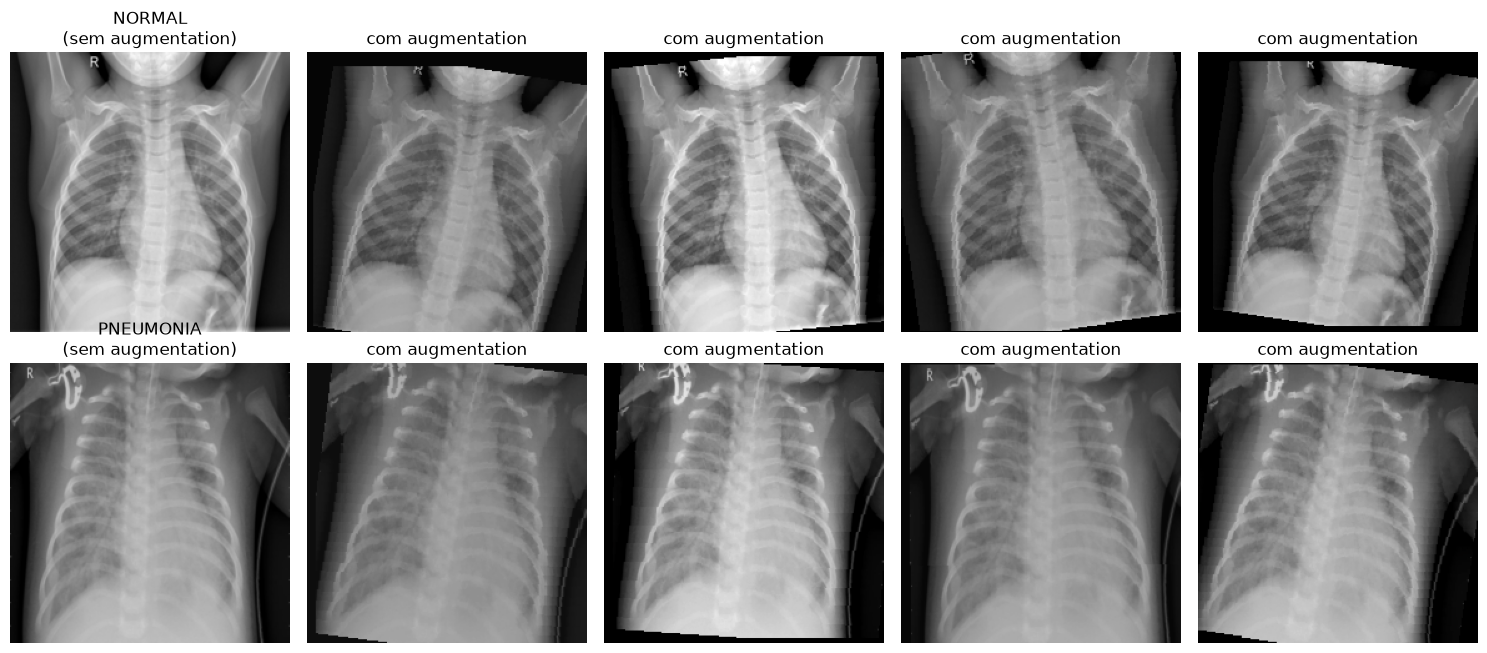

In [5]:
def para_exibir(tensor):
    # Desfaz o Normalize para a imagem poder ser desenhada (volta a valores de 0 a 1)
    media = torch.tensor(dados.MEDIA_IMAGENET).view(3, 1, 1)
    desvio = torch.tensor(dados.DESVIO_IMAGENET).view(3, 1, 1)
    imagem = (tensor * desvio + media).clamp(0, 1)
    return imagem.permute(1, 2, 0).numpy()      # (canais, altura, largura) -> (altura, largura, canais)


from PIL import Image

tf_avaliacao = dados.transformacoes_avaliacao()
tf_treino = dados.transformacoes_treino()

fig, eixos = plt.subplots(2, 5, figsize=(15, 6.5))
for linha, classe in enumerate(dados.CLASSES):
    caminho = df_treino[df_treino["classe"] == classe].iloc[0]["caminho"]
    original = Image.open(caminho)

    eixos[linha, 0].imshow(para_exibir(tf_avaliacao(original)), cmap="gray")
    eixos[linha, 0].set_title(f"{classe}\n(sem augmentation)")
    for coluna in range(1, 5):
        eixos[linha, coluna].imshow(para_exibir(tf_treino(original)), cmap="gray")
        eixos[linha, coluna].set_title("com augmentation")
for eixo in eixos.ravel():
    eixo.axis("off")

plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "02_data_augmentation.png", dpi=120)
plt.show()

## 4. DataLoaders

O modelo não recebe as imagens uma a uma: recebe 32 imagens de uma vez. O `DataLoader` carrega as imagens, aplica as transformações e agrupa em lotes. No treino, ele também embaralha a ordem a cada época.

In [6]:
loaders, tabelas = dados.criar_dataloaders(tamanho_lote=32)

imagens, rotulos = next(iter(loaders["treino"]))
print("Formato do lote de imagens:", tuple(imagens.shape), "(lote, canais, altura, largura)")
print("Rótulos do lote:", rotulos.tolist())
print("Lotes por época -> treino:", len(loaders["treino"]),
      "| val:", len(loaders["val"]), "| teste:", len(loaders["teste"]))

Formato do lote de imagens: (32, 3, 224, 224) (lote, canais, altura, largura)
Rótulos do lote: [0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0]
Lotes por época -> treino: 131 | val: 33 | teste: 20


## 5. Pesos de classe

O treino tem cerca de 3 imagens de pneumonia para cada imagem normal. Sem cuidado, o modelo pode aprender a favorecer a classe mais comum. Para compensar, damos **peso maior aos erros na classe rara** (NORMAL) na hora de calcular a perda durante o treino.

In [7]:
pesos = dados.pesos_de_classe(tabelas["treino"])
for classe, peso in zip(dados.CLASSES, pesos):
    print(f"{classe:10s} peso = {peso:.2f}")

NORMAL     peso = 1.95
PNEUMONIA  peso = 0.67


## 6. Conclusões

- O novo split separa cerca de 20% do treino para validação **sem misturar pacientes**, e o teste original continua intocado.
- Todas as imagens saem com o mesmo formato (3 canais, 224 x 224, normalizadas) e o treino usa data augmentation moderado.
- Os pesos de classe compensam o desbalanceamento.

